# 1. Theory
When $\theta=(\theta_1, \ldots, \theta_m)$ contains more than one parameter, we can use the mean field approximation:
$$q(\theta)=\prod_{i=1}^m q_i(\theta_i).$$

# 2. Model
* Data: $X_1, \ldots, X_n \sim Gamma(\alpha, \beta)$
* Prior: $\pi(\alpha,\beta)=Exp(\lambda)\times Exp(\lambda)$ with $\lambda=1$
* Variational Approximation: $q(\alpha, \beta)=N(\mu_\alpha, \sigma_\alpha^2)\times N(\mu_\beta, \sigma_\beta^2)$
* Log Likelihood: 
$$\log L(\alpha, \beta|X_{1:n})=n\alpha \log(\beta)-n\log(\Gamma(\alpha))+(\alpha-1)\sum_{i=1}^n \log(X_i)-\beta\sum_{i=1}^n X_i.$$
* Maximize Evidence Lower Bound (ELBO):
$$ELBO=E_{q(\theta)}\left[\log(L(\alpha, \beta|X_{1:n}))\right]-KL(q(\alpha, \beta)||\pi(\alpha, \beta))$$
* Calculation:
  1. Initial $\mu_\alpha, \sigma_\alpha, \mu_\beta, \sigma_\beta$
  2. Generate sample $\alpha_1, \ldots, \alpha_K$ from $q_1(\alpha)=N(\mu_\alpha, \sigma_\alpha^2)$
  3. Generate sample $\beta_1, \ldots, \beta_K$ from $q_2(\beta)=N(\mu_\beta, \sigma_\beta^2)$
  3. Approximation: 
  \begin{aligned}
    E_{q(\alpha, \beta)}\left[\log(L(\alpha, \beta|X_{1:n}))\right]&\approx \frac{1}{K}\sum_{k=1}^K \log(L(\alpha_k, \beta_k|X_{1:n})) \\
    &=\frac{1}{K}\sum_{k=1}^K n\alpha_k \log(\beta_k)-\frac{1}{K}\sum_{k=1}^K n\log(\Gamma(\alpha_k))\\
    &\quad\;+ \frac{1}{K}\sum_{k=1}^K(\alpha_k-1)\times \sum_{i=1}^n \log(X_i) - \frac{1}{K}\sum_{k=1}^K\beta_k\times \sum_{i=1}^n X_i
  \end{aligned}
  4. Approximation: 
  \begin{aligned}
 KL(q(\alpha, \beta)|| \pi(\alpha, \beta))&= \int q(\alpha, \beta)\log\left(\frac{q(\alpha, \beta)}{\pi(\alpha, \beta)}\right)d\alpha d\beta\\
 &= E_{q(\alpha, \beta)}\left[\log\left(\frac{q(\alpha, \beta)}{\pi(\alpha, \beta)}\right)\right]\\
 &= E_{q(\alpha, \beta)}\left[\log\left({q(\alpha, \beta)}\right)\right]-E_{q(\alpha, \beta)}\left[\log\left({\pi(\alpha, \beta)}\right)\right]\\
 &\approx \frac{1}{K} \sum_{k=1}^K \log(q(\alpha_k, \beta_k))-\frac{1}{K} \sum_{k=1}^K \log(\pi(\alpha_k, \beta_k))\\
 &= -\frac{1}{2}\log(2\pi)-\log(\sigma_\alpha)-\frac{1}{2\sigma_\alpha^2 K} \sum_{k=1}^K (\alpha_k-\mu_\alpha)^2\\
 &\quad-\frac{1}{2}\log(2\pi)-\log(\sigma_\beta)-\frac{1}{2\sigma_\beta^2 K} \sum_{k=1}^K (\beta_k-\mu_\beta)^2\\
 &\quad-\log(\lambda)+\frac{\lambda}{K}\sum_{k=1}^K  \alpha_k-\log(\lambda)+\frac{\lambda}{K}\sum_{k=1}^K  \beta_k\\
 &= -\log(\sigma_\alpha\sigma_\beta)-\frac{1}{K} \sum_{k=1}^K \log(\pi(\alpha_k, \beta_k))-\frac{1}{2\sigma_\beta^2 K} \sum_{k=1}^K (\beta_k-\mu_\beta)^2\\
 &\quad +\frac{\lambda}{K}\sum_{k=1}^K  (\alpha_k+\beta_k)+{\tt Constant},
  \end{aligned}
  where the constant does not depend on  $\mu_\alpha, \sigma_\alpha, \mu_\beta, \sigma_\beta$.
  5. Maximize ELBO using gradient algorithm: 
  $$ELBO(\mu_q, \sigma_q)=E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]-KL(q(\theta)|| \pi(\theta))$$
  6. Repeat Step 2-5 until convergence.

# 3. Code

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(1)

# Data Generation
n = 100
true_alpha = 3.0
true_beta = 2.0
lambda_param = 1
X = torch.distributions.Gamma(true_alpha, true_beta).sample((n,))

# Variational Gamma Estimation Model
class NN_VI_Gamma(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha_mu = nn.Parameter(torch.tensor(6.0))
        self.alpha_logsigma = nn.Parameter(torch.tensor(0.0))
        self.beta_mu = nn.Parameter(torch.tensor(6.0))
        self.beta_logsigma = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        K = 1000  # Monte Carlo samples
        n = x.shape[0]
        epsilon = torch.randn(K)  # K samples from N(0, 1)

        alpha_sample = self.alpha_mu + torch.exp(self.alpha_logsigma) * torch.randn(K)
        beta_sample = self.beta_mu + torch.exp(self.beta_logsigma) * torch.randn(K)

        log_likelihood = (
            n * alpha_sample * torch.log(beta_sample)
            - n * torch.lgamma(alpha_sample)
            + (alpha_sample - 1) * torch.sum(torch.log(X))
            - beta_sample * torch.sum(X)
        )
        log_likelihood = torch.mean(log_likelihood)

        log_q_theta = (
            -0.5 * torch.log(torch.tensor(2 * torch.pi))
            - self.alpha_logsigma
            - 0.5 * ((alpha_sample - self.alpha_mu) / torch.exp(self.alpha_logsigma))**2
            - 0.5 * torch.log(torch.tensor(2 * torch.pi))
            - self.beta_logsigma
            - 0.5 * ((beta_sample - self.beta_mu) / torch.exp(self.beta_logsigma))**2
        )
        
        log_p_theta = (
            torch.log(torch.tensor(1 / lambda_param)) - lambda_param * alpha_sample
            + torch.log(torch.tensor(1 / lambda_param)) - lambda_param * beta_sample
        )

        kl_div = torch.mean(log_q_theta - log_p_theta)
        return -log_likelihood + kl_div

# Model and Optimizer
model = NN_VI_Gamma()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Training Loop
for epoch in range(0, 2001):
    optimizer.zero_grad()
    loss = model(X)
    loss.backward()
    optimizer.step()

    if epoch % 400 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 192.0665
Epoch 400, Loss: 113.7810
Epoch 800, Loss: 113.7983
Epoch 1200, Loss: 113.7860
Epoch 1600, Loss: 113.8361
Epoch 2000, Loss: 113.8261


In [2]:
print(model.alpha_mu.item())
print(torch.exp(model.alpha_logsigma).item())

3.2803308963775635
0.16613908112049103


In [3]:
print(model.beta_mu.item())
print(torch.exp(model.beta_logsigma).item())

2.2368550300598145
0.12346263974905014


In [4]:
model.beta_mu.item()

2.2368550300598145

In [5]:
from scipy.stats import gamma
import numpy as np

# Fit Gamma distribution using MLE
X_array = X.numpy()  # Convert PyTorch tensor to NumPy array
fit_alpha, fit_loc, fit_beta = gamma.fit(X_array, floc=0)  # `floc=0` to fix location at 0 for shape-scale parameterization

print(f"MLE Fit Results: alpha = {fit_alpha:.4f}, beta = {1/fit_beta:.4f}")  # Note: `scale` is 1/beta

MLE Fit Results: alpha = 3.5679, beta = 2.4452


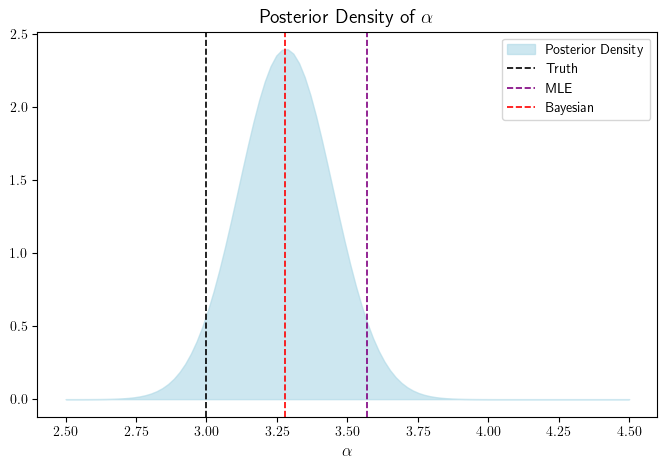

In [6]:
import matplotlib.pyplot as plt
#import seaborn as sns
from scipy.stats import norm
from matplotlib import rc
rc('text', usetex=True)  # For LaTeX-style labels

# Data
data2_alpha = np.linspace(true_alpha - 0.5, true_alpha + 1.5, 100)
posterior_density = norm.pdf(data2_alpha, loc=model.alpha_mu.item(), scale=torch.exp(model.alpha_logsigma).item())

# Plot
plt.figure(figsize=(8, 5))
plt.fill_between(data2_alpha, posterior_density, color='lightblue', alpha=0.6, label='Posterior Density')
plt.axvline(x=true_alpha, color='black', linestyle='--', linewidth=1.2, label='Truth')
plt.axvline(x=fit_alpha, color='purple', linestyle='--', linewidth=1.2, label='MLE')
plt.axvline(x=model.alpha_mu.item(), color='red', linestyle='--', linewidth=1.2, label='Bayesian')

# Labels and Styling
plt.title(r'Posterior Density of $\alpha$', fontsize=14)
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel('')
plt.legend(loc='upper right')
plt.grid(False)
plt.show()

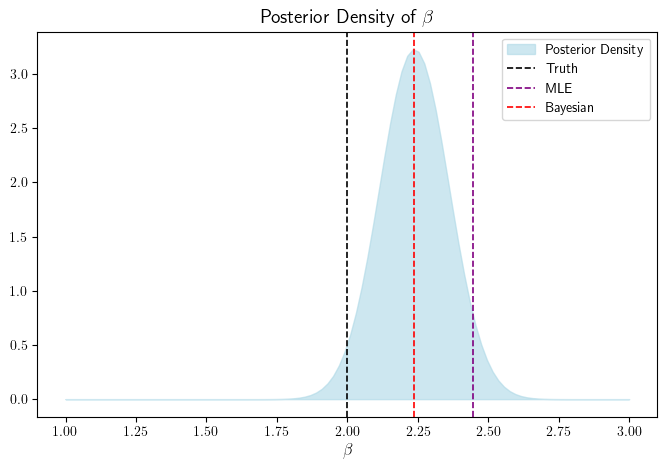

In [7]:
data2_beta = np.linspace(true_beta - 1, true_beta + 1, 100)
posterior_density_beta = norm.pdf(data2_beta, loc=model.beta_mu.item(), scale=torch.exp(model.beta_logsigma).item())

# Plot
plt.figure(figsize=(8, 5))
plt.fill_between(data2_beta, posterior_density_beta, color='lightblue', alpha=0.6, label='Posterior Density')
plt.axvline(x=true_beta, color='black', linestyle='--', linewidth=1.2, label='Truth')
plt.axvline(x=1/fit_beta, color='purple', linestyle='--', linewidth=1.2, label='MLE')  # Recall: scipy gamma.fit returns scale = 1/beta
plt.axvline(x=model.beta_mu.item(), color='red', linestyle='--', linewidth=1.2, label='Bayesian')

# Labels and Styling
plt.title(r'Posterior Density of $\beta$', fontsize=14)
plt.xlabel(r'$\beta$', fontsize=12)
plt.ylabel('')
plt.legend(loc='upper right')
plt.grid(False)
plt.show()